In [11]:
# The following line fixes the KeyError in cell nScPvV7zOGzr:
# df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
!pip install pandas numpy matplotlib seaborn plotly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Cleaned_Cafe_Sales.csv to Cleaned_Cafe_Sales.csv


In [4]:
df = pd.read_csv(list(uploaded.keys())[0])

df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day,Weekday
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023.0,9.0,8.0,Friday
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,2023.0,5.0,16.0,Tuesday
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,2023.0,7.0,19.0,Wednesday
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27,2023.0,4.0,27.0,Thursday
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023.0,6.0,11.0,Sunday


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Item              10000 non-null  object 
 2   Quantity          10000 non-null  float64
 3   Price Per Unit    10000 non-null  float64
 4   Total Spent       10000 non-null  float64
 5   Payment Method    10000 non-null  object 
 6   Location          10000 non-null  object 
 7   Transaction Date  9540 non-null   object 
 8   Year              9540 non-null   float64
 9   Month             9540 non-null   float64
 10  Day               9540 non-null   float64
 11  Weekday           9540 non-null   object 
dtypes: float64(6), object(6)
memory usage: 937.6+ KB


In [6]:
df.isnull().sum()

,0
Transaction ID,0
Item,0
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,460
Year,460
Month,460


In [7]:
df = df.dropna()

In [8]:
df = df.drop_duplicates()

In [13]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

In [16]:
total_sales = df['Total Spent'].sum()

print("Total Sales =", total_sales)

Total Sales = 85246.5


In [18]:
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date,Year,Month,Day
count,9540.000000,9540.000000,9540.000000,9540,9540.0,9540.000000,9540.000000
mean,3.024109,2.952673,8.935692,2023-07-01 23:00:31.698113536,2023.0,6.524004,15.738679
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00,2023.0,1.000000,1.000000
25%,2.000000,2.000000,4.000000,2023-04-01 00:00:00,2023.0,4.000000,8.000000
50%,3.000000,3.000000,8.000000,2023-07-02 00:00:00,2023.0,7.000000,16.000000
75%,4.000000,4.000000,12.000000,2023-10-02 00:00:00,2023.0,10.000000,23.000000
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00,2023.0,12.000000,31.000000
std,1.384186,1.243449,5.827677,NaN,0.0,3.449446,8.761003


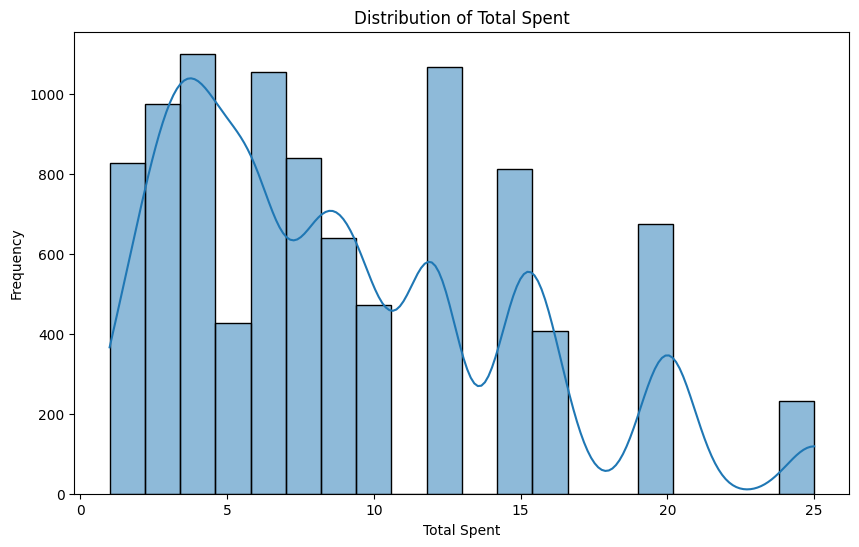

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Total Spent'], bins=20, kde=True)
plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_1917/3005750755.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_spent_by_item.index, y=total_spent_by_item.values, palette='viridis')


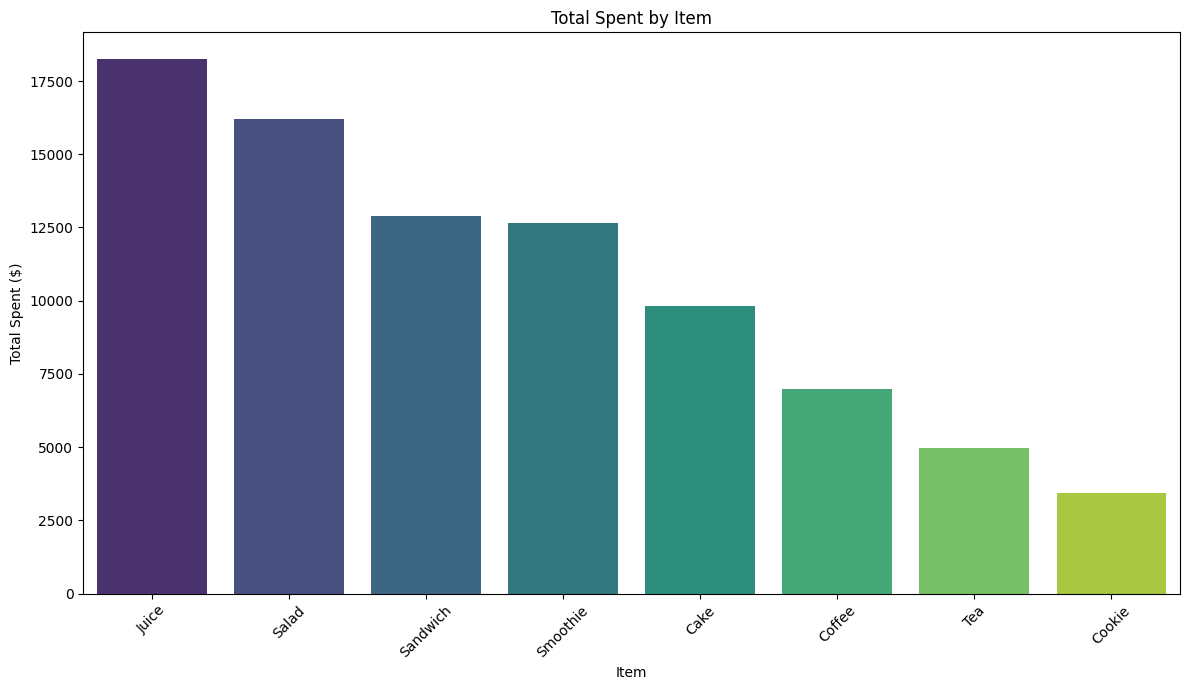

In [20]:
total_spent_by_item = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=total_spent_by_item.index, y=total_spent_by_item.values, palette='viridis')
plt.title('Total Spent by Item')
plt.xlabel('Item')
plt.ylabel('Total Spent ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

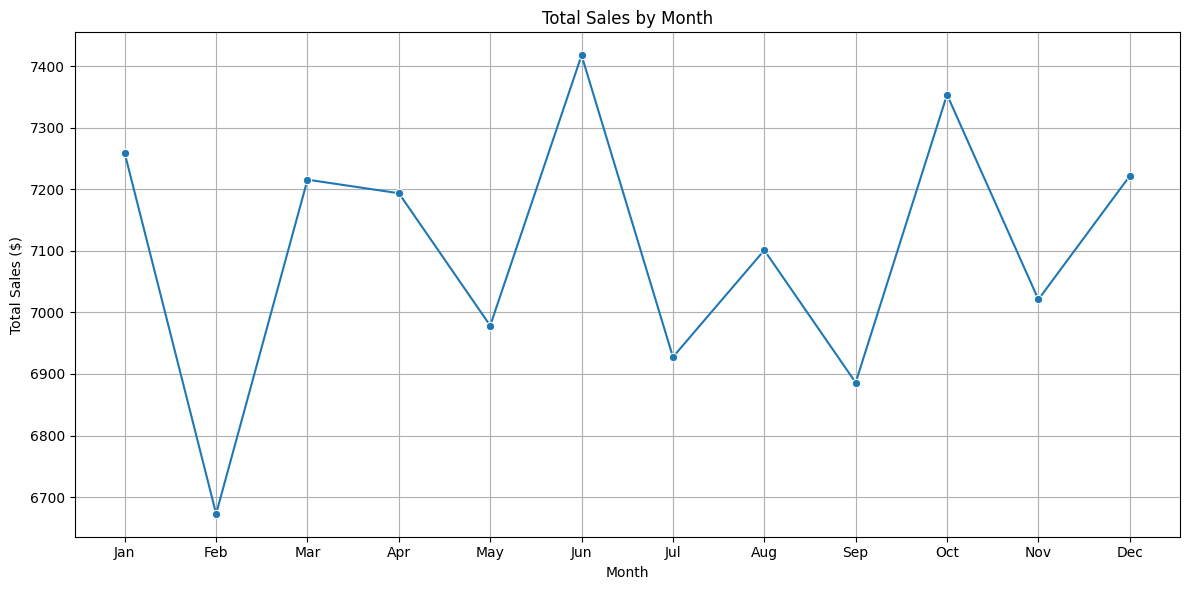

In [21]:
monthly_sales = df.groupby('Month')['Total Spent'].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1917/3136128117.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_spent_by_location.index, y=total_spent_by_location.values, palette='coolwarm')


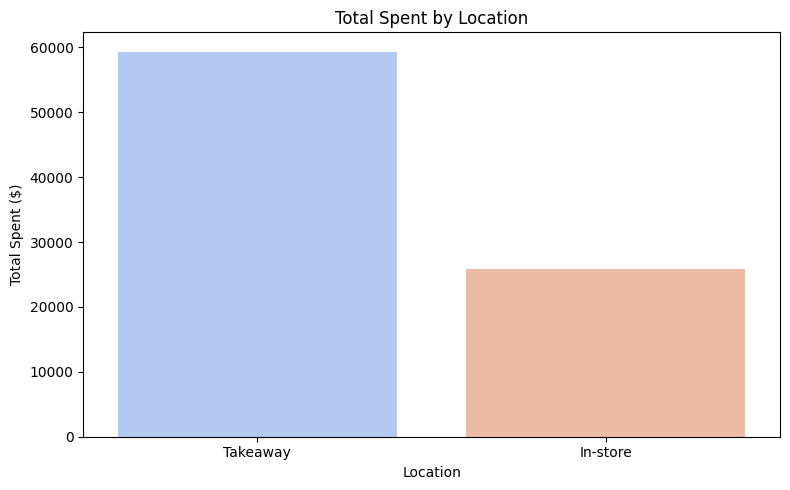

In [22]:
total_spent_by_location = df.groupby('Location')['Total Spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=total_spent_by_location.index, y=total_spent_by_location.values, palette='coolwarm')
plt.title('Total Spent by Location')
plt.xlabel('Location')
plt.ylabel('Total Spent ($)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1917/1164460820.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_spent_by_payment_method.index, y=total_spent_by_payment_method.values, palette='plasma')


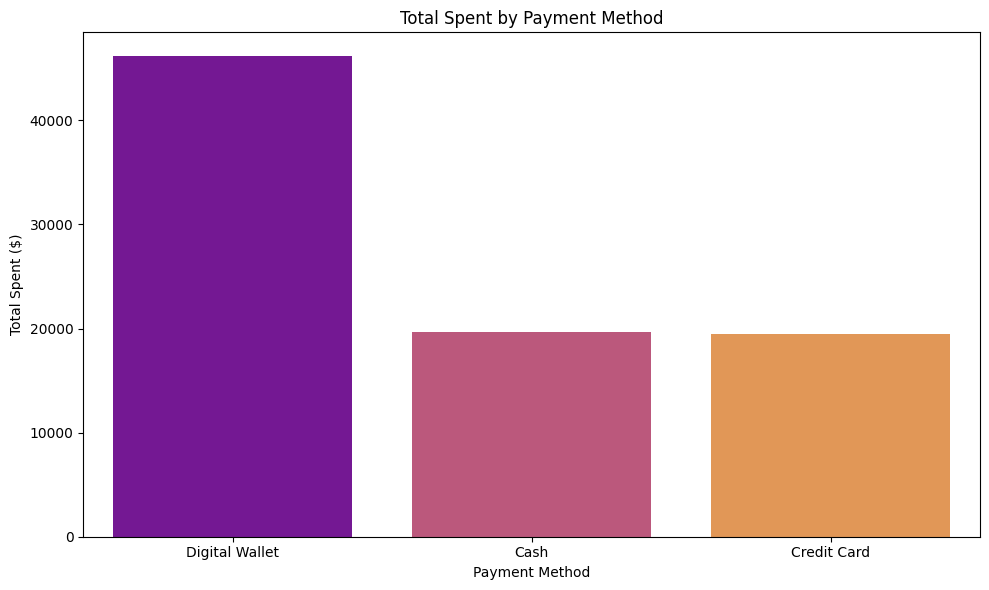

In [23]:
total_spent_by_payment_method = df.groupby('Payment Method')['Total Spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=total_spent_by_payment_method.index, y=total_spent_by_payment_method.values, palette='plasma')
plt.title('Total Spent by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Spent ($)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1917/3925016964.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_spent_by_weekday.index, y=total_spent_by_weekday.values, palette='viridis')


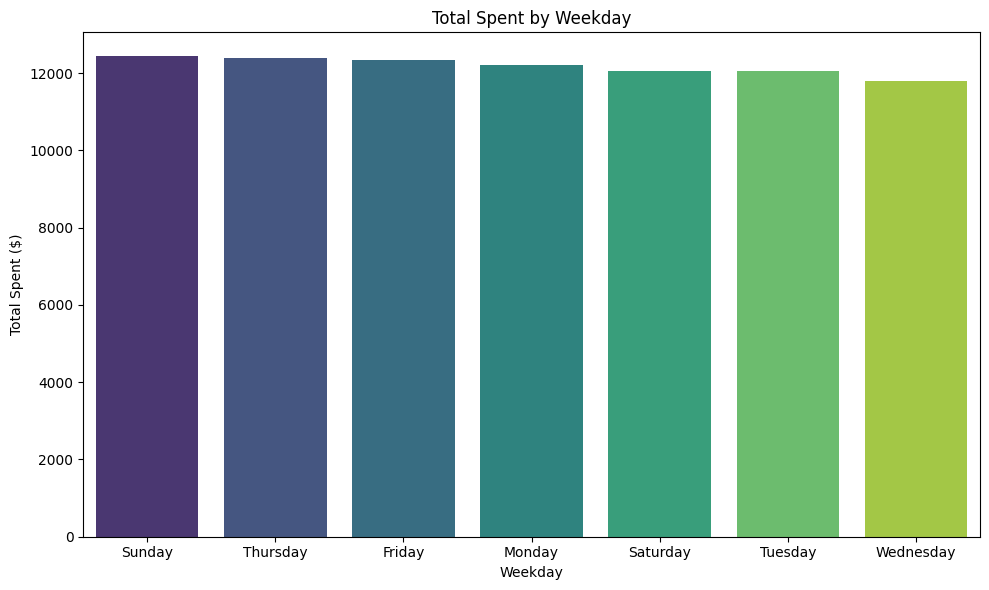

In [24]:
total_spent_by_weekday = df.groupby('Weekday')['Total Spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=total_spent_by_weekday.index, y=total_spent_by_weekday.values, palette='viridis')
plt.title('Total Spent by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Total Spent ($)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1917/3270318280.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_spent_by_hour.index, y=total_spent_by_hour.values, palette='magma')


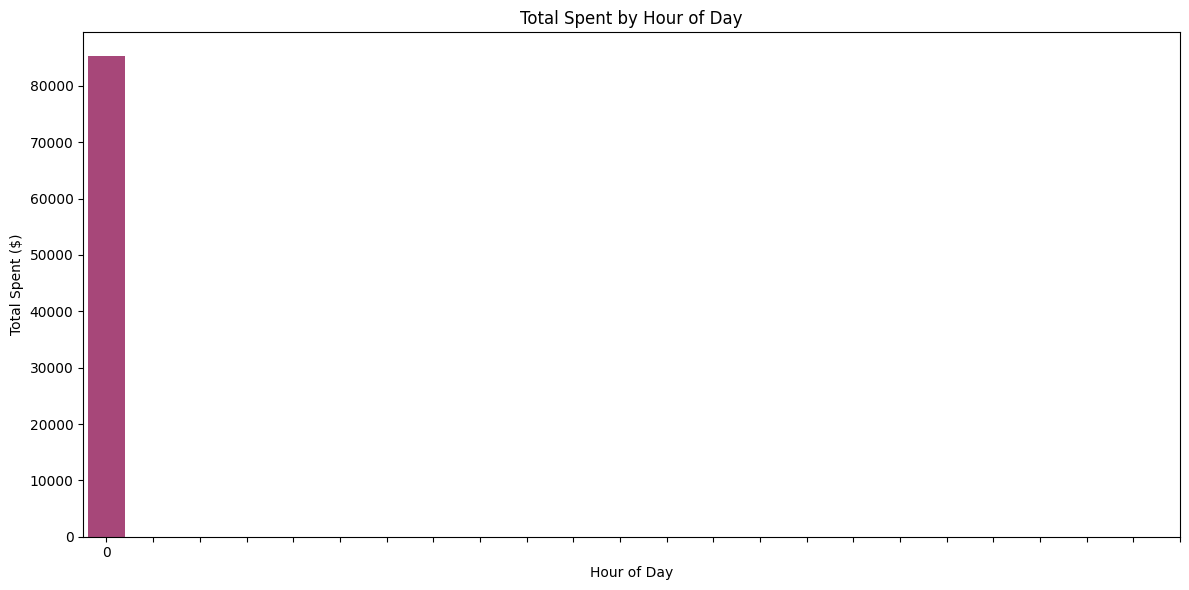

In [25]:
df['Hour'] = df['Transaction Date'].dt.hour

total_spent_by_hour = df.groupby('Hour')['Total Spent'].sum()

plt.figure(figsize=(12, 6))
sns.barplot(x=total_spent_by_hour.index, y=total_spent_by_hour.values, palette='magma')
plt.title('Total Spent by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Spent ($)')
plt.xticks(range(24)) # Ensure all 24 hours are shown if data exists
plt.tight_layout()
plt.show()

/tmp/ipykernel_1917/295657155.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_per_item.index, y=avg_price_per_item.values, palette='coolwarm')


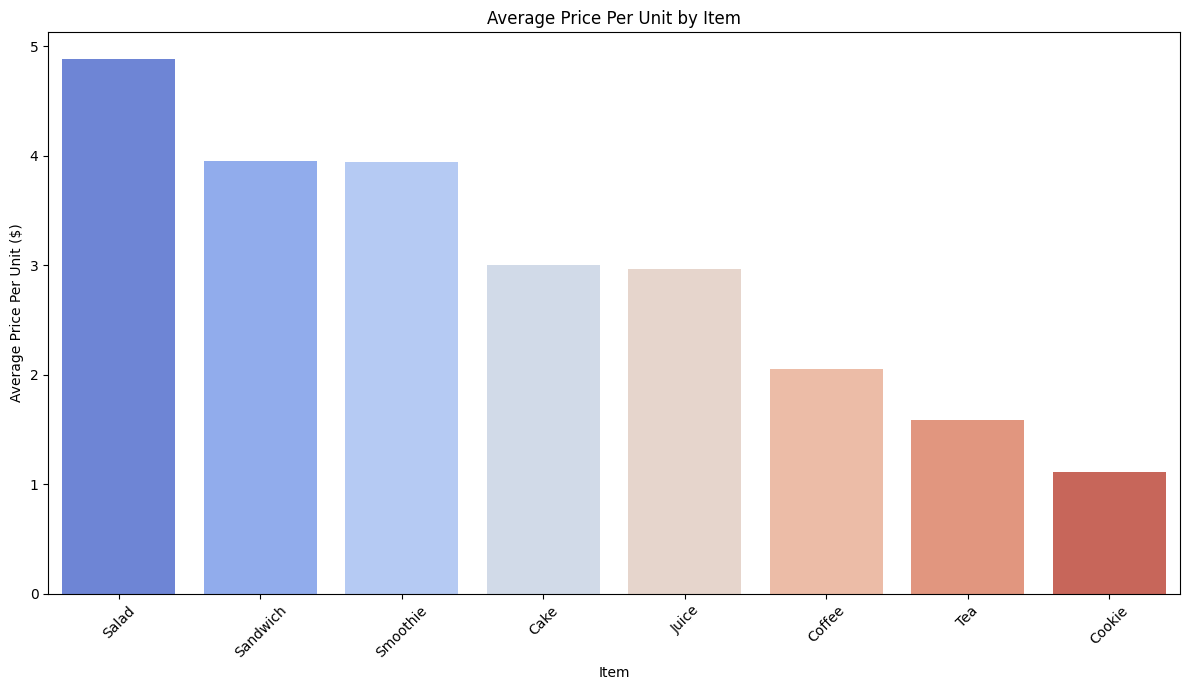

In [26]:
avg_price_per_item = df.groupby('Item')['Price Per Unit'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_price_per_item.index, y=avg_price_per_item.values, palette='coolwarm')
plt.title('Average Price Per Unit by Item')
plt.xlabel('Item')
plt.ylabel('Average Price Per Unit ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1917/4008122003.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_quantity_by_item.index, y=total_quantity_by_item.values, palette='plasma')


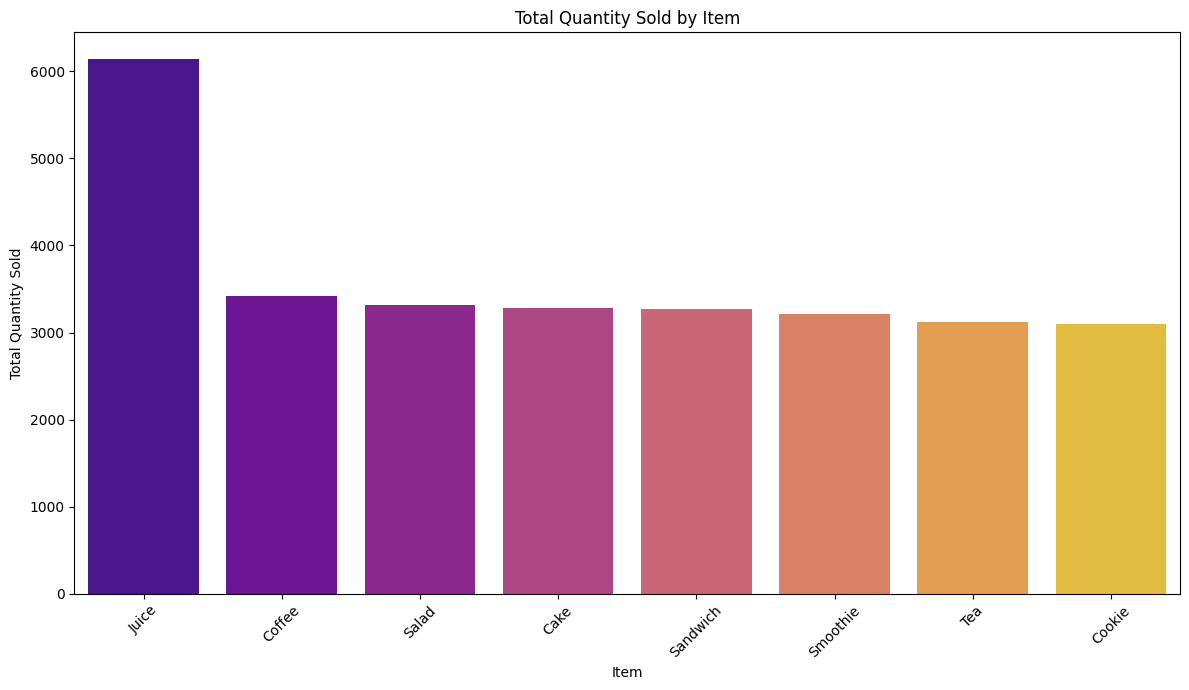

In [27]:
total_quantity_by_item = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=total_quantity_by_item.index, y=total_quantity_by_item.values, palette='plasma')
plt.title('Total Quantity Sold by Item')
plt.xlabel('Item')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

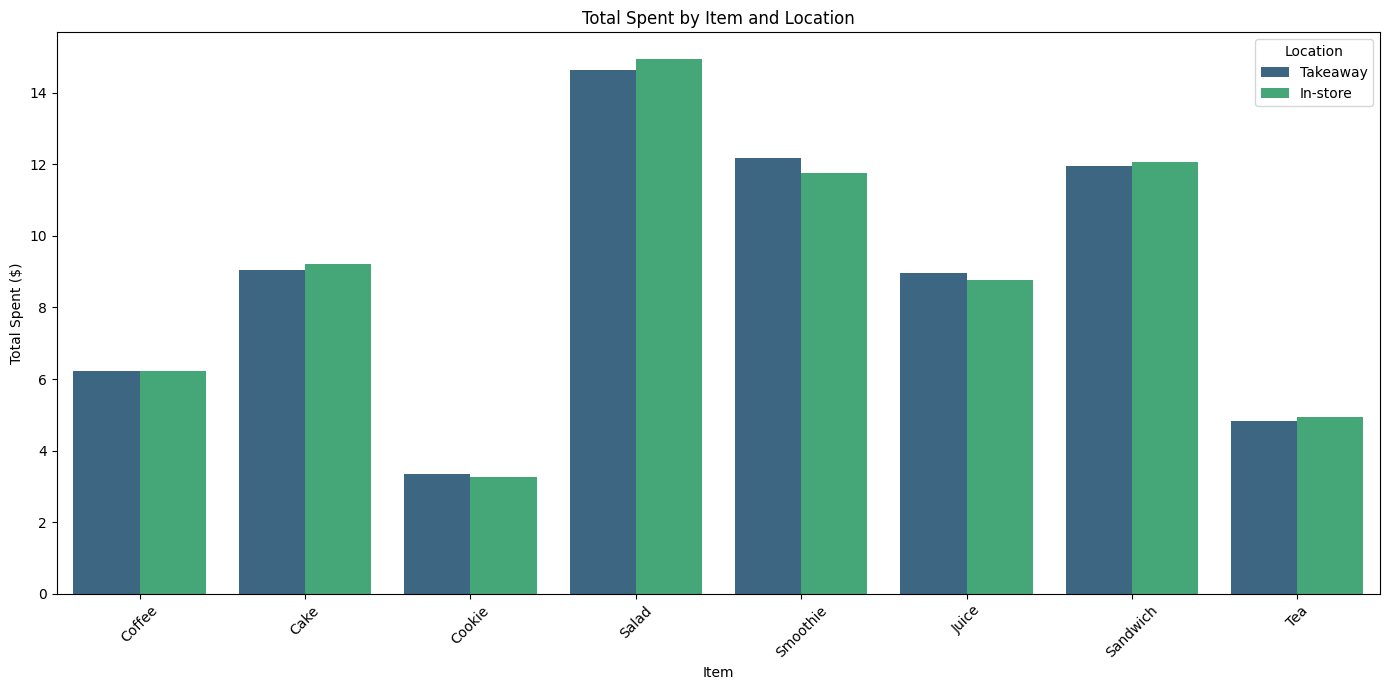

In [29]:
plt.figure(figsize=(14, 7))
sns.barplot(data=df, x='Item', y='Total Spent', hue='Location', palette='viridis', errorbar=None)
plt.title('Total Spent by Item and Location')
plt.xlabel('Item')
plt.ylabel('Total Spent ($)')
plt.xticks(rotation=45)
plt.legend(title='Location')
plt.tight_layout()
plt.show()

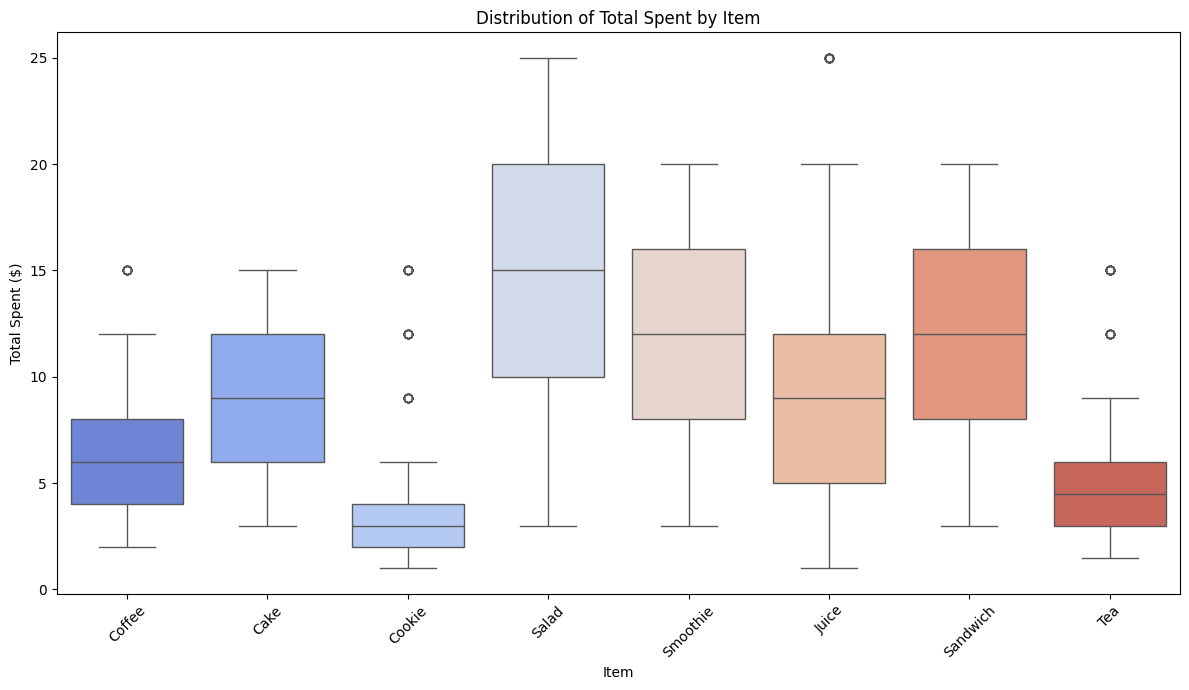

In [31]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='Item', y='Total Spent', hue='Item', palette='coolwarm', legend=False)
plt.title('Distribution of Total Spent by Item')
plt.xlabel('Item')
plt.ylabel('Total Spent ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

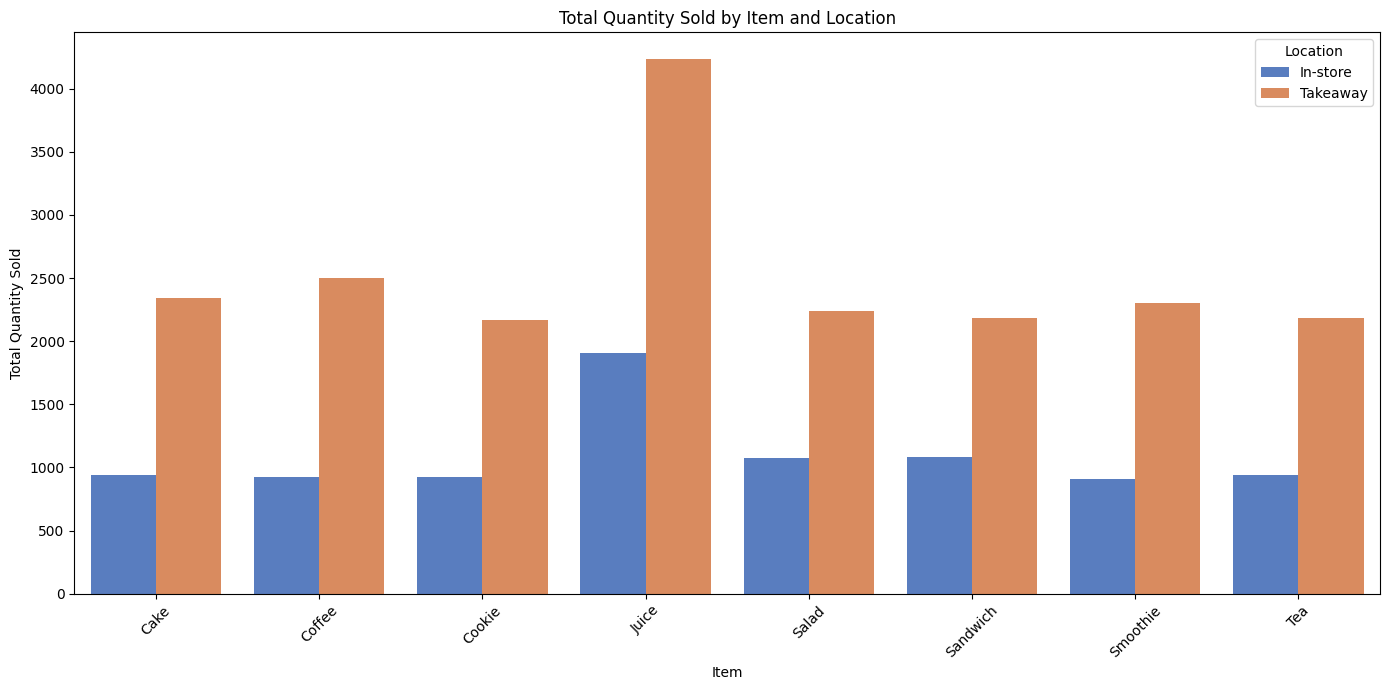

In [32]:
total_quantity_by_item_location = df.groupby(['Item', 'Location'])['Quantity'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=total_quantity_by_item_location, x='Item', y='Quantity', hue='Location', palette='muted')
plt.title('Total Quantity Sold by Item and Location')
plt.xlabel('Item')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.legend(title='Location')
plt.tight_layout()
plt.show()

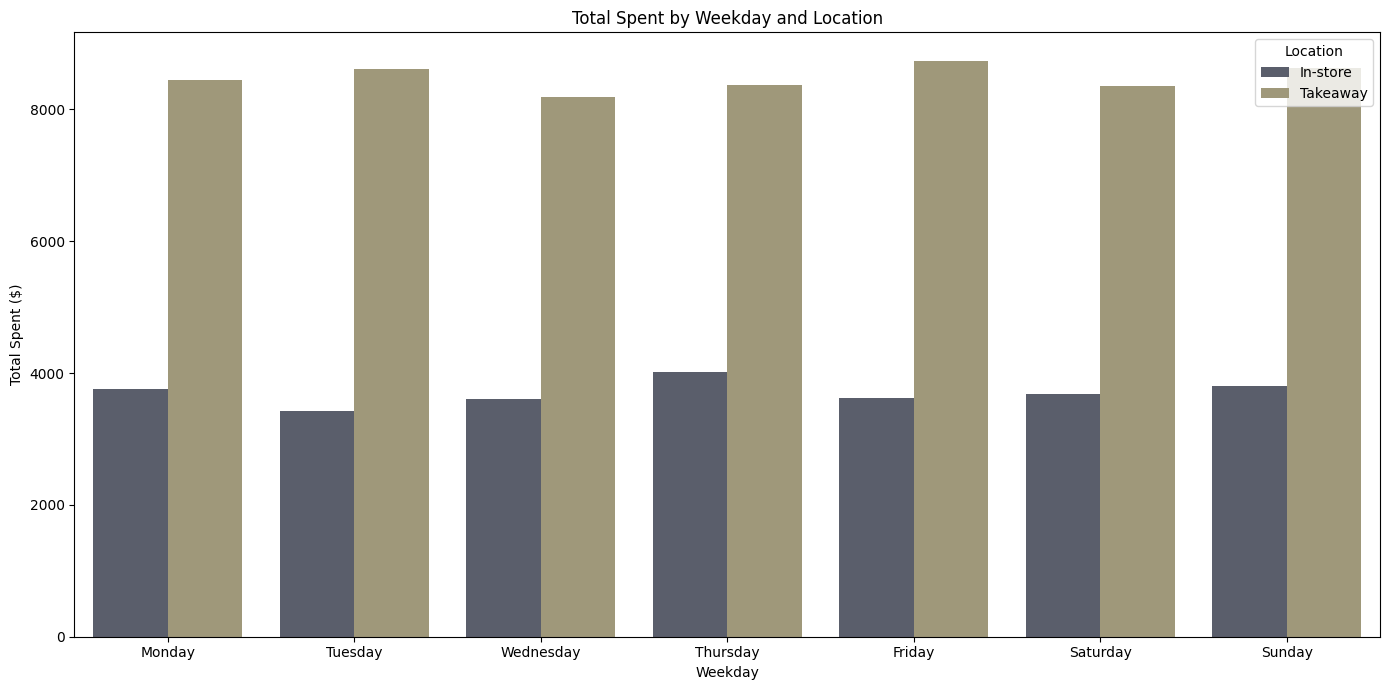

In [33]:
total_spent_weekday_location = df.groupby(['Weekday', 'Location'])['Total Spent'].sum().reset_index()

# Define the order of weekdays for better visualization
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
total_spent_weekday_location['Weekday'] = pd.Categorical(total_spent_weekday_location['Weekday'], categories=weekday_order, ordered=True)
total_spent_weekday_location = total_spent_weekday_location.sort_values('Weekday')

plt.figure(figsize=(14, 7))
sns.barplot(data=total_spent_weekday_location, x='Weekday', y='Total Spent', hue='Location', palette='cividis')
plt.title('Total Spent by Weekday and Location')
plt.xlabel('Weekday')
plt.ylabel('Total Spent ($)')
plt.legend(title='Location')
plt.tight_layout()
plt.show()

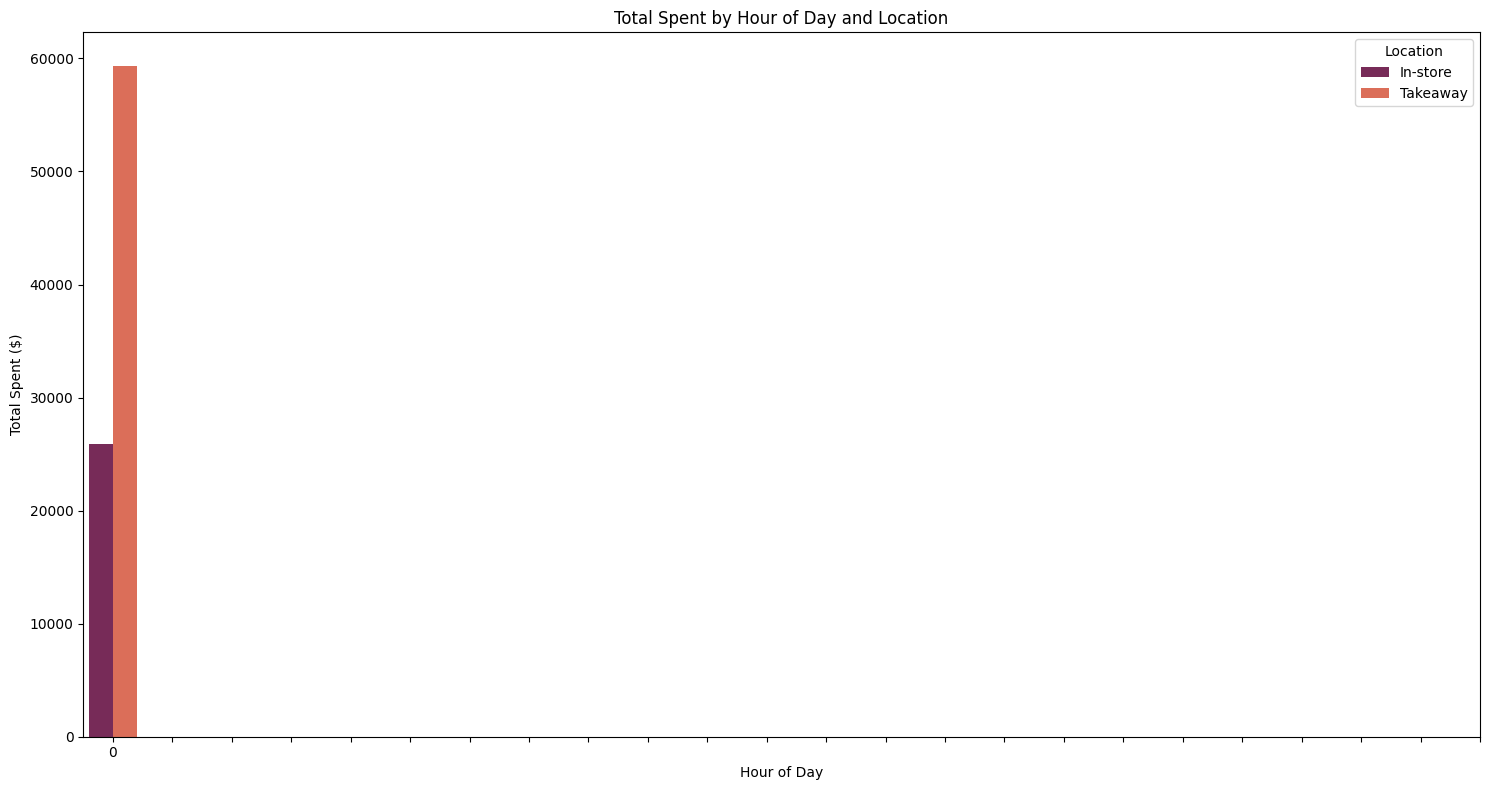

In [34]:
total_spent_hour_location = df.groupby(['Hour', 'Location'])['Total Spent'].sum().reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(data=total_spent_hour_location, x='Hour', y='Total Spent', hue='Location', palette='rocket')
plt.title('Total Spent by Hour of Day and Location')
plt.xlabel('Hour of Day')
plt.ylabel('Total Spent ($)')
plt.xticks(range(24)) # Ensure all 24 hours are shown
plt.legend(title='Location')
plt.tight_layout()
plt.show()

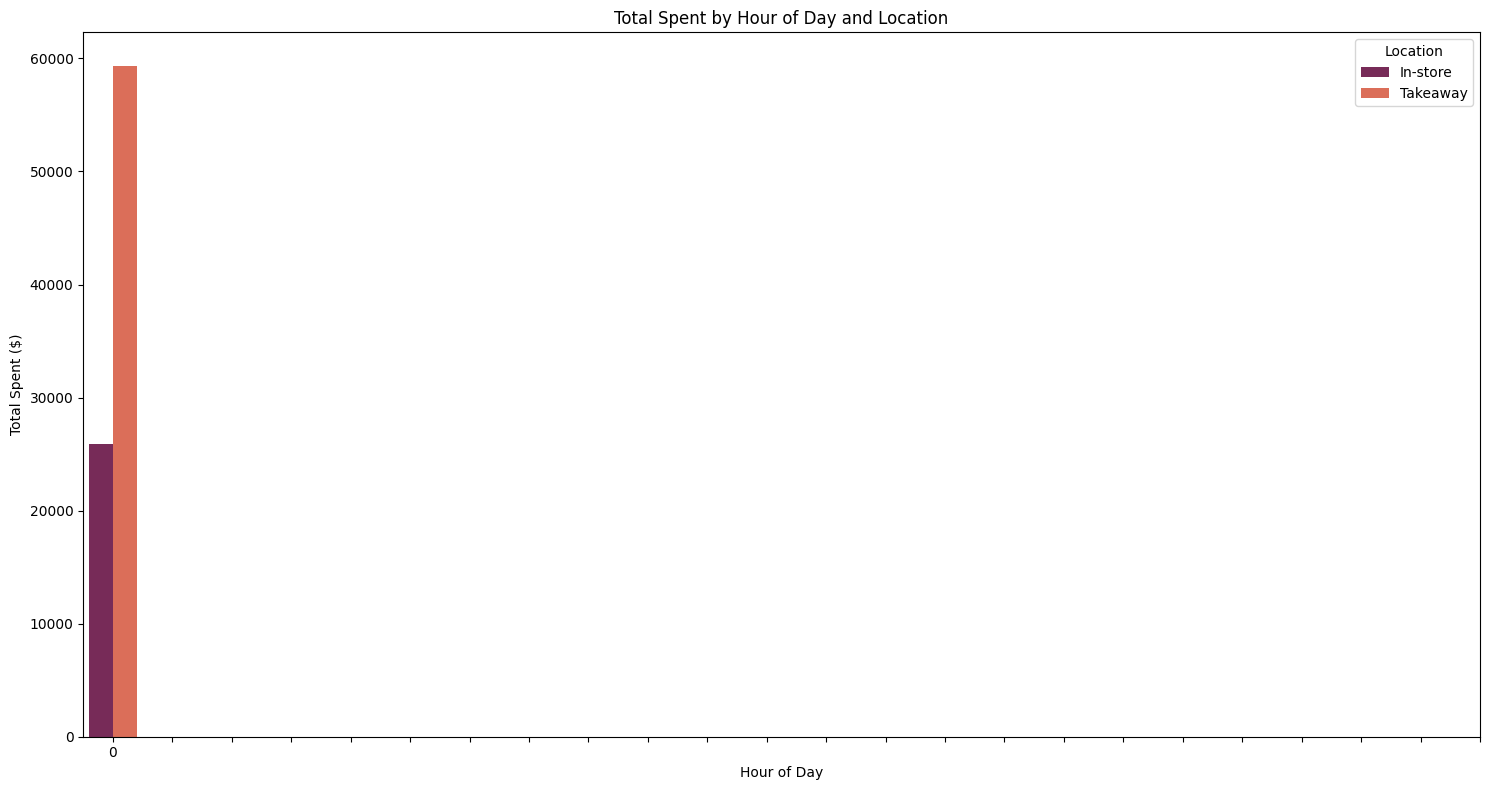

In [35]:
total_spent_hour_location = df.groupby(['Hour', 'Location'])['Total Spent'].sum().reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(data=total_spent_hour_location, x='Hour', y='Total Spent', hue='Location', palette='rocket')
plt.title('Total Spent by Hour of Day and Location')
plt.xlabel('Hour of Day')
plt.ylabel('Total Spent ($)')
plt.xticks(range(24)) # Ensure all 24 hours are shown
plt.legend(title='Location')
plt.tight_layout()
plt.show()

In [36]:
print("Sample of 'Transaction Date' and 'Hour' columns:")
print(df[['Transaction Date', 'Hour']].head())

print("\nData types of 'Transaction Date' and 'Hour' columns:")
print(df[['Transaction Date', 'Hour']].dtypes)

Sample of 'Transaction Date' and 'Hour' columns:
  Transaction Date  Hour
0       2023-09-08     0
1       2023-05-16     0
2       2023-07-19     0
3       2023-04-27     0
4       2023-06-11     0

Data types of 'Transaction Date' and 'Hour' columns:
Transaction Date    datetime64[ns]
Hour                         int32
dtype: object


In [38]:
rfm['Segment'] = 'Regular'

rfm.loc[
    (rfm['Frequency'] >= 5) &
    (rfm['Monetary'] >= rfm['Monetary'].median()),
    'Segment'
] = 'Loyal'

rfm.loc[
    rfm['Recency'] > 180,
    'Segment'
] = 'Inactive'

rfm.head()

NameError: name 'rfm' is not defined

### Creating Synthetic Customer IDs for RFM Analysis

Since the current dataset (`df`) does not contain a `customer_id` column, we need to create one to perform Recency, Frequency, and Monetary (RFM) analysis. For demonstration purposes, I will generate synthetic `CustomerID` values by randomly assigning each transaction to one of 100 assumed unique customers. This will allow us to calculate RFM metrics for these synthetic customers.

Keep in mind that in a real-world scenario, you would use actual customer identifiers to ensure meaningful segmentation.

In [39]:
# Generate synthetic Customer IDs (e.g., 100 unique customers)
num_customers = 100
df['CustomerID'] = np.random.randint(1, num_customers + 1, size=len(df))

# Define a snapshot date for recency calculation (one day after the latest transaction)
snapshot_date = df['Transaction Date'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics
rfm = df.groupby('CustomerID').agg(
    Recency=('Transaction Date', lambda date: (snapshot_date - date.max()).days),
    Frequency=('Transaction ID', 'count'),
    Monetary=('Total Spent', 'sum')
).reset_index()

display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,1,6,79,712.5
1,2,3,97,846.5
2,3,21,77,632.5
3,4,2,106,916.5
4,5,10,101,900.5


Now that the `rfm` DataFrame has been created with `Recency`, `Frequency`, and `Monetary` columns, we can apply your segmentation logic.

In [40]:
# Apply the segmentation logic provided by the user
rfm['Segment'] = 'Regular'

rfm.loc[
    (rfm['Frequency'] >= 5) &
    (rfm['Monetary'] >= rfm['Monetary'].median()),
    'Segment'
] = 'Loyal'

rfm.loc[
    rfm['Recency'] > 180,
    'Segment'
] = 'Inactive'

# Display the head of the RFM DataFrame with the new 'Segment' column
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary,Segment
0,1,6,79,712.5,Regular
1,2,3,97,846.5,Regular
2,3,21,77,632.5,Regular
3,4,2,106,916.5,Loyal
4,5,10,101,900.5,Loyal


### Visualizing Customer Segments

To better understand the customer base, let's visualize the distribution of the newly created customer segments. This will show us the proportion of customers categorized as 'Loyal', 'Regular', and 'Inactive'.

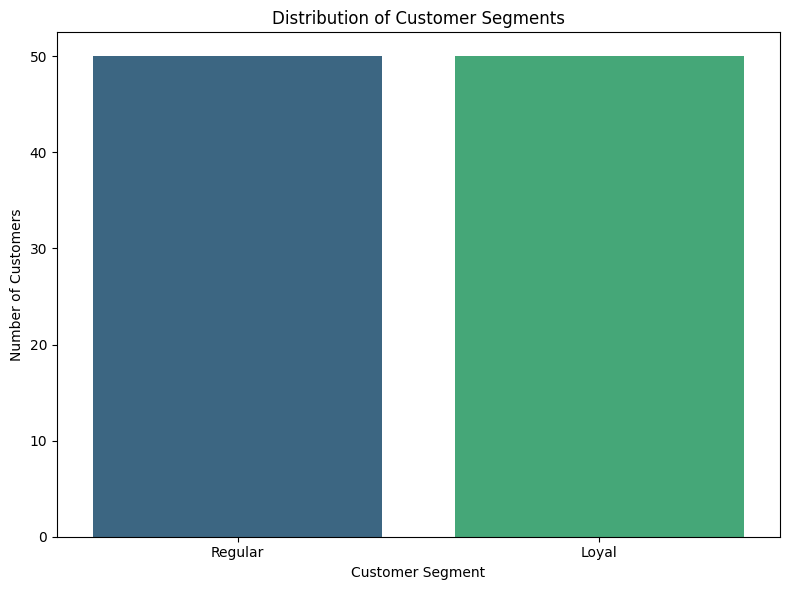

Customer Segment Distribution:
   Segment  Count
0  Regular     50
1    Loyal     50


In [43]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

plt.figure(figsize=(8, 6))
sns.barplot(data=segment_counts, x='Segment', y='Count', hue='Segment', palette='viridis', legend=False)
plt.title('Distribution of Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print("Customer Segment Distribution:")
print(segment_counts)

In [42]:
segment = rfm['Segment'].value_counts().reset_index()

segment.columns = ['Segment', 'Customers']

fig = px.pie(
    segment,
    names='Segment',
    values='Customers',
    title='Customer Segmentation'
)

fig.show()

In [44]:
df.to_csv("Processed_Task3_Data.csv", index=False)

print("File Saved Successfully")

File Saved Successfully


In [45]:
files.download("Processed_Task3_Data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>